In [24]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, AdamW
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt

# Ensure GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [25]:
# Load the datasets
train_file_path = 'Books11.csv'  # Replace with your training dataset path
test_file_path = 'DVD11.csv'  # Replace with your test dataset path

# Load data and limit rows for memory
train_data = pd.read_csv(train_file_path, nrows=12000)
test_data = pd.read_csv(test_file_path)

# Verify columns exist
assert 'review_body' in train_data.columns and 'star_rating' in train_data.columns, "Required columns missing!"

# Map star ratings to sentiments
train_data['sentiment'] = train_data['star_rating']
test_data['sentiment'] = test_data['star_rating']

# Encode sentiments
le = LabelEncoder()
train_data['sentiment_encoded'] = le.fit_transform(train_data['sentiment'])
test_data['sentiment_encoded'] = le.transform(test_data['sentiment'])

print(f"Classes: {le.classes_}")
print(f"Train Class Distribution:\n{train_data['sentiment_encoded'].value_counts()}")
print(f"Test Class Distribution:\n{test_data['sentiment_encoded'].value_counts()}")

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_data(texts, tokenizer, max_length):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

MAX_LENGTH = 128
train_encodings = tokenize_data(train_data['review_body'], tokenizer, MAX_LENGTH)
test_encodings = tokenize_data(test_data['review_body'], tokenizer, MAX_LENGTH)

train_labels = torch.tensor(train_data['sentiment_encoded'].values)
test_labels = torch.tensor(test_data['sentiment_encoded'].values)


Classes: [0 1 2]
Train Class Distribution:
sentiment_encoded
2    9596
0    1478
1     926
Name: count, dtype: int64
Test Class Distribution:
sentiment_encoded
2    9918
0    1384
1    1083
Name: count, dtype: int64


In [26]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [27]:
class SentimentClassifierWithBiLSTM(nn.Module):
    def __init__(self, n_classes):
        super(SentimentClassifierWithBiLSTM, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=256,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(256 * 2, n_classes)  # Bi-directional

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        lstm_output, _ = self.lstm(outputs.last_hidden_state)
        avg_pool = torch.mean(lstm_output, 1)
        output = self.drop(avg_pool)
        return self.out(output)

model = SentimentClassifierWithBiLSTM(n_classes=3)
model = model.to(device)


In [28]:
def train_epoch(model, data_loader, criterion, optimizer):
    model.train()
    total_loss, correct_predictions = 0, 0

    for batch in tqdm(data_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)
        correct_predictions += torch.sum(preds == labels)

        loss.backward()
        optimizer.step()

    return total_loss / len(data_loader), correct_predictions.double() / len(data_loader.dataset)


def validate_epoch(model, data_loader, criterion):
    model.eval()
    total_loss, correct_predictions = 0, 0

    with torch.no_grad():
        for batch in tqdm(data_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels)

    return total_loss / len(data_loader), correct_predictions.double() / len(data_loader.dataset)


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

EPOCHS = 5
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_accuracy = validate_epoch(model, test_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
100%|██████████| 775/775 [01:25<00:00,  9.02it/s]


Epoch 1/5
Train Loss: 0.4544, Accuracy: 0.8433
Val Loss: 0.3565, Accuracy: 0.8684


100%|██████████| 775/775 [01:25<00:00,  9.06it/s]


Epoch 2/5
Train Loss: 0.2999, Accuracy: 0.8947
Val Loss: 0.3587, Accuracy: 0.8711


100%|██████████| 775/775 [01:25<00:00,  9.05it/s]


Epoch 3/5
Train Loss: 0.1966, Accuracy: 0.9327
Val Loss: 0.4062, Accuracy: 0.8710


100%|██████████| 775/775 [01:25<00:00,  9.04it/s]


Epoch 4/5
Train Loss: 0.1198, Accuracy: 0.9607
Val Loss: 0.4593, Accuracy: 0.8706


100%|██████████| 775/775 [01:25<00:00,  9.05it/s]

Epoch 5/5
Train Loss: 0.0810, Accuracy: 0.9763
Val Loss: 0.5023, Accuracy: 0.8706


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70      1384
           1       0.43      0.30      0.36      1083
           2       0.92      0.96      0.94      9918

    accuracy                           0.87     12385
   macro avg       0.70      0.64      0.66     12385
weighted avg       0.86      0.87      0.86     12385

Confusion Matrix:
[[ 899  157  328]
 [ 206  328  549]
 [  92  270 9556]]


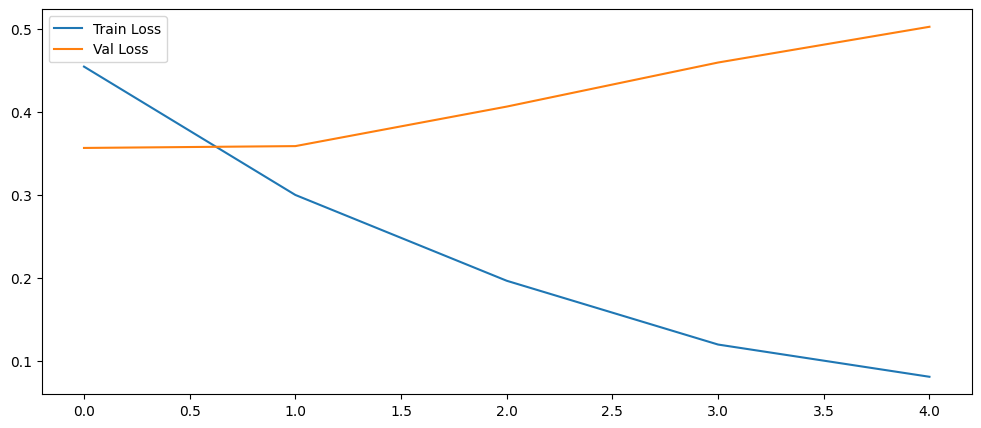

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

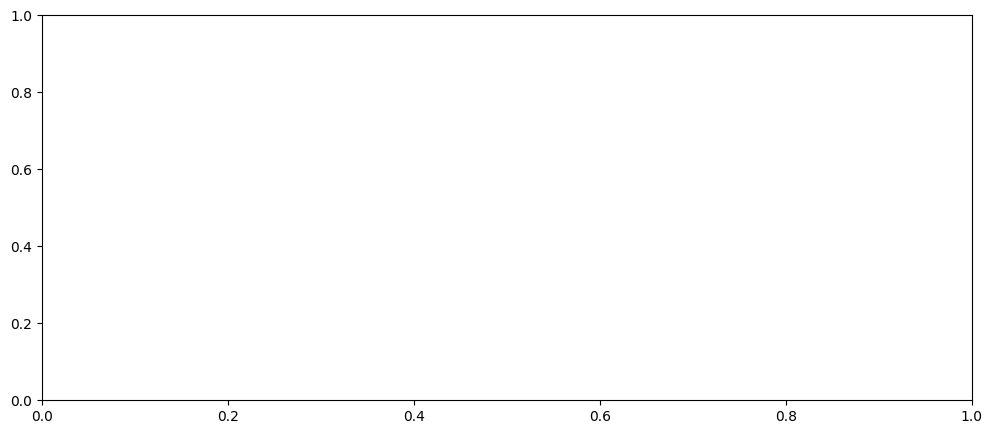

In [31]:
# Evaluate model
def evaluate_model(model, data_loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            _, preds = torch.max(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

evaluate_model(model, test_loader)

# Plot training vs validation metrics
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.show()
